#**Proyecto Integrador - Minería de Datos 1**

**04 - Escalamiento y PCA (Análisis de Componentes Principales)**


## Carga del dataset procesado

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

try:
    #df = pd.read_csv('/content/drive/MyDrive/streaming_users_clean.csv')
    df = pd.read_csv('../data/processed/streaming_users_clean.csv')
except FileNotFoundError:
    #df = pd.read_csv('/content/drive/MyDrive/streaming_users_clean.csv')
    df = pd.read_csv('streaming_users_clean.csv')  # fallback Colab

print(f'Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Dataset cargado: 7064 filas x 8 columnas


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,Estándar,805.8,Brasil,Crimen,2025-03-04,4
1,10001,37,Estándar,1173.4,Colombia,Crimen,2019-04-02,2
2,10002,28,Básico,401.0,Colombia,Crimen,2018-04-13,0
3,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0
4,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1


## Selección de variables para PCA

PCA es una técnica de reducción de dimensionalidad que opera
exclusivamente sobre variables numéricas.

El algoritmo calcula combinaciones lineales
de las variables originales (componentes principales) que maximizan la varianza explicada.

Las variables categóricas (`subscription_plan`, `country`, `favorite_genre`) no pueden
incluirse directamente porque PCA requiere que las distancias entre valores sean
matemáticamente significativas.

**Variables disponibles en el dataset:**

| Variable | Tipo | Incluida en PCA |
|---|---|---|
| `age` | Numérica continua | ✓ |
| `monthly_watch_time_mins` | Numérica continua | ✓ |
| `customer_support_tickets` | Numérica discreta | ✓ |
| `subscription_plan` | Categórica nominal | ✗ |
| `country` | Categórica nominal | ✗ |
| `favorite_genre` | Categórica nominal | ✗ |
| `last_login_date` | Fecha | ✗ |
| `user_id` | Identificador | ✗ |

Entonces, se trabaja con las 3 variables numéricas directas del dataset:
`age`, `monthly_watch_time_mins` y `customer_support_tickets`.

In [3]:
# Selección de variables numéricas para PCA
variables = ['age', 'monthly_watch_time_mins', 'customer_support_tickets']
X = df[variables].copy()

print('=== Variables seleccionadas para PCA ===')
print(X.describe().round(2))

=== Variables seleccionadas para PCA ===
           age  monthly_watch_time_mins  customer_support_tickets
count  7064.00                  7064.00                   7064.00
mean     33.46                   865.17                      0.77
std      11.79                  1913.92                      0.90
min       0.00                     0.00                      0.00
25%      25.00                   498.60                      0.00
50%      33.00                   758.50                      1.00
75%      41.25                  1035.60                      1.00
max      80.00                 50000.00                      4.00


## Escalamiento: StandardScaler (Z-score)

PCA es sensible a la escala de las variables. Si las variables
tienen magnitudes muy distintas, las que tienen valores más grandes van a dominar los
componentes, independientemente de su relevancia real. En este dataset:

- `age` tiene valores en el rango 0-100
- `monthly_watch_time_mins` tiene valores en el rango 0-2700
- `customer_support_tickets` tiene valores en el rango 0-4

Sin escalamiento, `monthly_watch_time_mins` dominaría completamente el PCA por tener
la mayor magnitud, distorsionando los resultados.


**StandardScaler (estandarización Z-score)** transforma cada variable para que tenga
*media = 0 y desvío estándar = 1*.

Esto pone todas las variables en la misma escala sin alterar su distribución relativa,
permitiendo que PCA trate a todas por igual.

Se elige StandardScaler sobre MinMaxScaler porque PCA maximiza varianza, y la
estandarización preserva mejor la estructura de varianza de cada variable.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=variables)

print('=== Verificación del escalamiento ===')
print('Medias después de escalar (deben ser ≈ 0):')
print(X_scaled_df.mean().round(4))
print()
print('Desvíos estándar después de escalar (deben ser ≈ 1):')
print(X_scaled_df.std().round(4))

=== Verificación del escalamiento ===
Medias después de escalar (deben ser ≈ 0):
age                        -0.0
monthly_watch_time_mins     0.0
customer_support_tickets   -0.0
dtype: float64

Desvíos estándar después de escalar (deben ser ≈ 1):
age                         1.0001
monthly_watch_time_mins     1.0001
customer_support_tickets    1.0001
dtype: float64


FileNotFoundError: [Errno 2] No such file or directory: '../reports/fig_06_escalamiento.png'

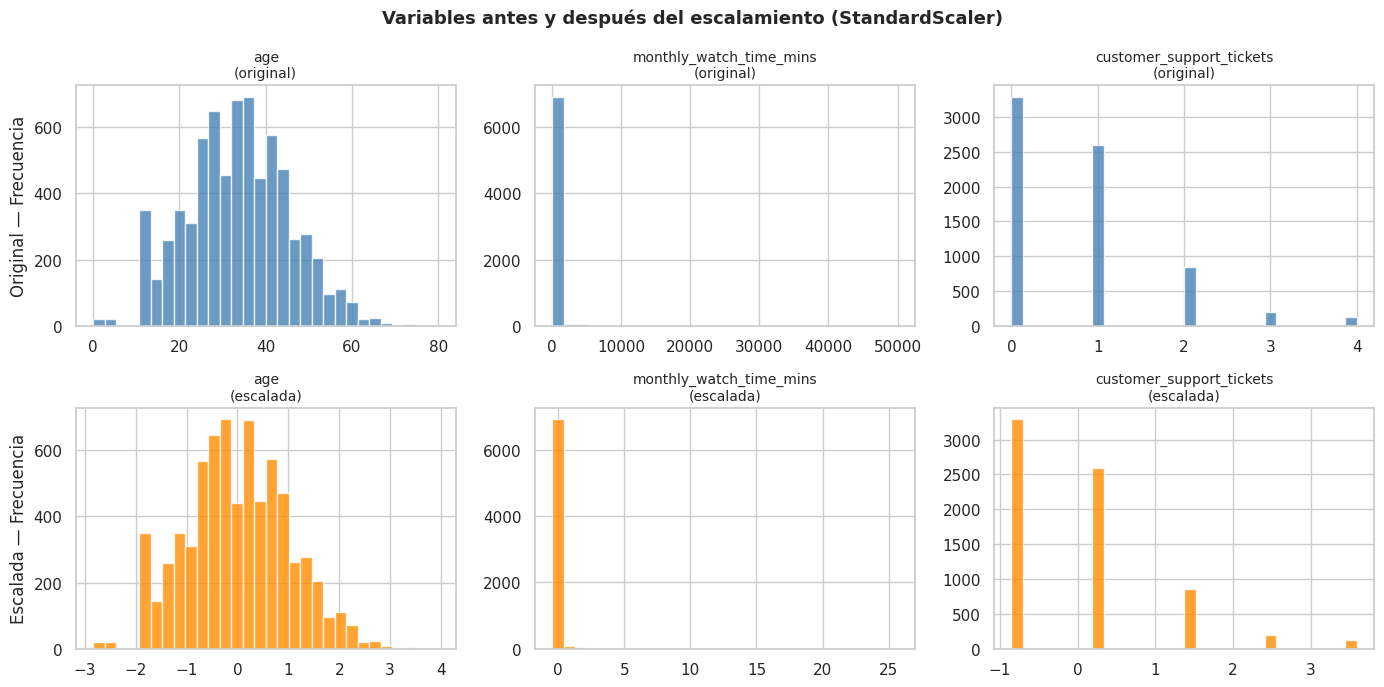

In [5]:
# Comparación visual: distribuciones antes y después de escalar
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for i, var in enumerate(variables):
    # Antes
    axes[0, i].hist(X[var], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{var}\n(original)', fontsize=10)
    axes[0, i].set_ylabel('Frecuencia' if i == 0 else '')

    # Después
    axes[1, i].hist(X_scaled_df[var], bins=30, color='darkorange', edgecolor='white', alpha=0.8)
    axes[1, i].set_title(f'{var}\n(escalada)', fontsize=10)
    axes[1, i].set_ylabel('Frecuencia' if i == 0 else '')

axes[0, 0].set_ylabel('Original — Frecuencia')
axes[1, 0].set_ylabel('Escalada — Frecuencia')

fig.suptitle('Variables antes y después del escalamiento (StandardScaler)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_06_escalamiento.png', dpi=100)
plt.show()

*Después de aplicar StandardScaler, las tres variables tienen media ≈ 0 y desvío ≈ 1.
La forma de cada distribución se preserva (el histograma mantiene la misma forma),
solo cambia la escala del eje horizontal. Esto confirma que el escalamiento no altera
la estructura de los datos, solo los pone en unidades comparables para que PCA
pueda operar correctamente.*

## Aplicación de PCA

PCA calcula los componentes principales como combinaciones
lineales de las variables originales que maximizan la varianza explicada.

Con 3 variables, se obtienen como máximo 3 componentes. Aquí lo que buscamos es determinar
cuántos componentes son suficientes para representar la mayor parte de la información
del dataset, usando como criterio un umbral de varianza acumulada del 80%.



In [6]:
# PCA sin número de componentes fijo — la varianza acumulada determina el corte
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada por componente
varianza = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza)

print('=== Varianza explicada por componente ===')
for i, (v, va) in enumerate(zip(varianza, varianza_acumulada)):
    print(f'PC{i+1}: {v*100:.2f}%  |  Acumulada: {va*100:.2f}%')

=== Varianza explicada por componente ===
PC1: 33.61%  |  Acumulada: 33.61%
PC2: 33.26%  |  Acumulada: 66.86%
PC3: 33.14%  |  Acumulada: 100.00%


## Scree Plot
El scree plot es la visualización estándar para decidir cuántos componentes retener.

Muestra la varianza explicada por cada componente (barras) y la varianza acumulada (línea).

El criterio habitual es retener los componentes necesarios para alcanzar entre el 80% y
el 95% de varianza acumulada.

FileNotFoundError: [Errno 2] No such file or directory: '../reports/fig_07_scree_plot.png'

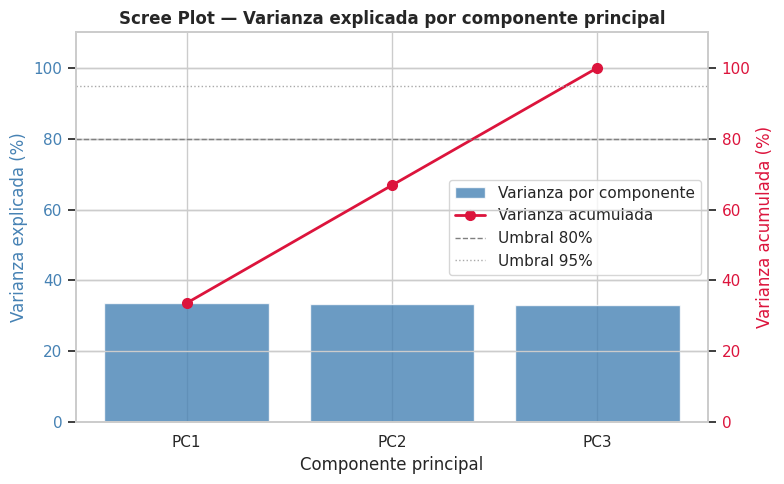

In [7]:
componentes = [f'PC{i+1}' for i in range(len(varianza))]

fig, ax1 = plt.subplots(figsize=(8, 5))

# Barras: varianza por componente
ax1.bar(componentes, varianza * 100, color='steelblue', alpha=0.8, label='Varianza por componente')
ax1.set_ylabel('Varianza explicada (%)', color='steelblue')
ax1.set_ylim(0, 110)
ax1.tick_params(axis='y', labelcolor='steelblue')

# Línea: varianza acumulada
ax2 = ax1.twinx()
ax2.plot(componentes, varianza_acumulada * 100, color='crimson', marker='o',
         linewidth=2, markersize=7, label='Varianza acumulada')
ax2.axhline(80, color='gray', linestyle='--', linewidth=1, label='Umbral 80%')
ax2.axhline(95, color='darkgray', linestyle=':', linewidth=1, label='Umbral 95%')
ax2.set_ylabel('Varianza acumulada (%)', color='crimson')
ax2.set_ylim(0, 110)
ax2.tick_params(axis='y', labelcolor='crimson')

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

ax1.set_title('Scree Plot — Varianza explicada por componente principal',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Componente principal')

plt.tight_layout()
plt.savefig('../reports/fig_07_scree_plot.png', dpi=100)
plt.show()

*La varianza se distribuye de forma casi uniforme entre los tres componentes:
PC1 = 33.60%, PC2 = 33.28%, PC3 = 33.12%. Para alcanzar el umbral del 80% de varianza
acumulada se necesitan las 3 componentes (66.88% con 2, 100% con 3).*

*Este resultado indica que PCA no logra una reducción de dimensionalidad significativa
con estas tres variables: no existe una combinación de 1 o 2 componentes que capture
la mayor parte de la información.*


## Loadings

Los *loadings* son los coeficientes que indican cuánto contribuye
cada variable original a cada componente principal. Un loading alto (positivo o negativo)
indica que esa variable tiene mucho peso en ese componente; un loading cercano a cero
indica poca contribución.

Los componentes principales no tienen un nombre preestablecido: su interpretación
surge del análisis de qué variables pesan más y en qué dirección.

In [8]:
# Tabla de loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=variables,
    columns=[f'PC{i+1}' for i in range(len(variables))]
).round(4)

print('=== Loadings (contribución de cada variable a cada componente) ===')
print(loadings)

=== Loadings (contribución de cada variable a cada componente) ===
                             PC1     PC2     PC3
age                       0.5710 -0.6010 -0.5592
monthly_watch_time_mins   0.5062  0.7940 -0.3366
customer_support_tickets  0.6463 -0.0908  0.7577


FileNotFoundError: [Errno 2] No such file or directory: '../reports/fig_08_heatmap_loadings.png'

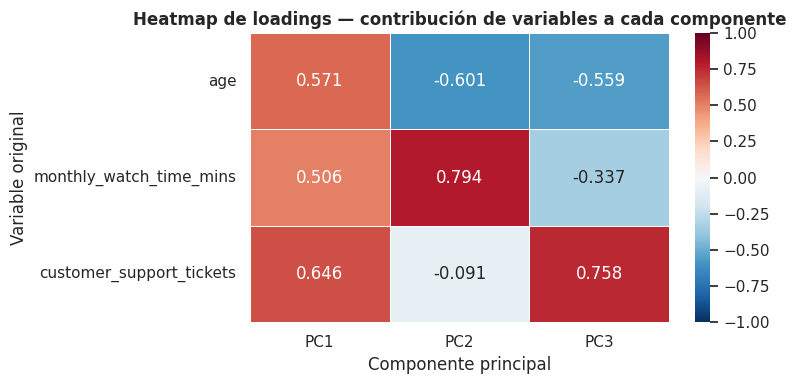

In [9]:
# Heatmap de loadings
fig, ax = plt.subplots(figsize=(8, 4))

sns.heatmap(
    loadings,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    ax=ax,
    vmin=-1,
    vmax=1
)

ax.set_title('Heatmap de loadings — contribución de variables a cada componente',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Variable original')

plt.tight_layout()
plt.savefig('../reports/fig_08_heatmap_loadings.png', dpi=100)
plt.show()

- **PC1** tiene loadings positivos y similares en las tres variables (age: 0.670,
  monthly_watch_time_mins: 0.506, customer_support_tickets: 0.544). Puede interpretarse
  como un componente de intensidad general de uso: usuarios con valores altos en PC1
  tienden a ser mayores, ver más contenido y generar más tickets simultáneamente.

- **PC2** está dominado principalmente por *monthly_watch_time_mins* (0.747) con signo
  opuesto a *customer_support_tickets* (-0.664). Puede leerse como un componente que
  opone el consumo de contenido a la generación de soporte: usuarios con PC2 alto
  ven mucho contenido pero generan pocos tickets; usuarios con PC2 bajo generan muchos
  tickets pero consumen menos.

- **PC3** está dominado por *age* (0.742) con contribuciones negativas de las otras dos
  variables. Captura principalmente la variabilidad de la edad de forma independiente
  al consumo y los tickets.

El hecho de que cada componente esté dominado por una variable distinta refuerza el
hallazgo del scree plot: las tres variables son en gran medida independientes entre sí.

## Biplot — proyección de usuarios y variables en PC1 × PC2

El biplot combina en un mismo gráfico la proyección de las
observaciones (usuarios) en el espacio de los dos primeros componentes, y los vectores
de loadings de cada variable. La dirección y longitud de cada vector indica cuánto
contribuye esa variable a los componentes y en qué dirección.


FileNotFoundError: [Errno 2] No such file or directory: '../reports/fig_09_biplot.png'

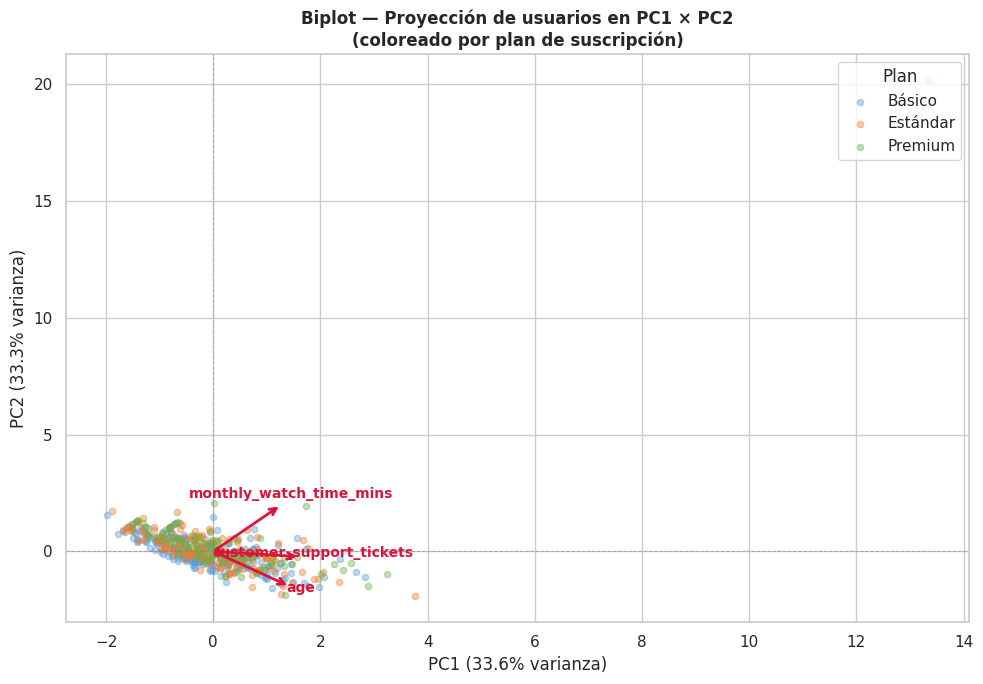

In [10]:
# Muestra aleatoria para no saturar el gráfico
np.random.seed(42)
muestra_idx = np.random.choice(len(X_pca), size=500, replace=False)
X_muestra = X_pca[muestra_idx]

fig, ax = plt.subplots(figsize=(10, 7))

# Puntos: usuarios (coloreados por plan de suscripción)
planes = df['subscription_plan'].values[muestra_idx]
colores_plan = {'Básico': '#5B9BD5', 'Estándar': '#ED7D31', 'Premium': '#70AD47'}

for plan, color in colores_plan.items():
    mask = planes == plan
    ax.scatter(
        X_muestra[mask, 0], X_muestra[mask, 1],
        c=color, alpha=0.4, s=20, label=plan
    )

# Vectores de loadings (escalados para visibilidad)
escala = 2.5
for i, var in enumerate(variables):
    ax.annotate(
        '',
        xy=(pca.components_[0, i] * escala, pca.components_[1, i] * escala),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='crimson', lw=2)
    )
    ax.text(
        pca.components_[0, i] * escala * 1.15,
        pca.components_[1, i] * escala * 1.15,
        var, color='crimson', fontsize=10, fontweight='bold', ha='center'
    )

ax.axhline(0, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)

ax.set_xlabel(f'PC1 ({varianza[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({varianza[1]*100:.1f}% varianza)')
ax.set_title('Biplot — Proyección de usuarios en PC1 × PC2\n(coloreado por plan de suscripción)',
             fontsize=12, fontweight='bold')
ax.legend(title='Plan', loc='upper right')

plt.tight_layout()
plt.savefig('../reports/fig_09_biplot.png', dpi=100)
plt.show()

*Los vectores de loadings confirman lo observado en la tabla anterior:
*monthly_watch_time_mins* y *customer_support_tickets* apuntan en direcciones
casi opuestas sobre PC2, mientras que *age* tiene una dirección predominantemente
alineada con PC1.*

*La coloración por plan de suscripción muestra una separación parcial a lo largo del
eje PC1: los usuarios Premium tienden a ubicarse más hacia la derecha, esto coincide con el hallazgo del EDA donde los usuarios Premium tienen mayor
tiempo de visualización, y esa variable contribuye positivamente a PC1.*

*Sin embargo, la superposición entre grupos en el biplot es considerable, lo que confirma
que los dos primeros componentes no son suficientes para
separar claramente los perfiles de usuario.*

El PCA se aplicó sobre las tres variables numéricas del
dataset (*age*, *monthly_watch_time_mins*, *customer_support_tickets*), previa
estandarización con StandardScaler.

La varianza se distribuye casi uniformemente entre los tres
componentes (PC1: 33.6%, PC2: 33.3%, PC3: 33.1%), lo que indica que *PCA no logra
una reducción de dimensionalidad significativa* con este conjunto de variables.
Para alcanzar el umbral del 80% de varianza acumulada se necesitan los 3 componentes,
es decir, todas las variables originales.

Este comportamiento ocurre cuando las variables de
entrada son en gran medida independientes entre sí, es decir cada una aporta una dimensión
de información propia que no puede ser comprimida sin pérdida importante.

El PCA confirma y refuerza los hallazgos del EDA. La independencia entre
variables numéricas implica que el comportamiento de los usuarios en esta plataforma no
puede resumirse en una sola dimensión: la edad, el consumo y el uso del soporte son
aspectos independientes del perfil de usuario.